Explorative Datenanalyse und Bereinigung
Dieses Notebook bereinigt die bereitgestellte CSV. Die Spalten in der Datei heißen age, gender und hand; gender wird hier als Entsprechung der angeforderten Spalte Sex verwendet.
Regeln
- Vierstellige Werte von 1900 bis 2026 in age werden als Geburtsjahr interpretiert und mit 2026 − Geburtsjahr in ein näherungsweises Alter umgerechnet.
- Ein- und zweistellige Alterswerte von 1 bis 120 bleiben erhalten.
- 0, dreistellige Werte, fehlende und sonstige ungültige Werte in age führen zum Ausschluss der gesamten Zeile.
- Fehlende Werte oder 0 in gender bzw. hand führen ebenfalls zum Ausschluss.
- Eine 0 in mindestens einem der festgelegten Frage-Items führt zum Ausschluss.
Ohne Geburtsdatum kann das aus einem Geburtsjahr berechnete Alter um bis zu ein Jahr abweichen.

In [85]:
# Import und Setup

import subprocess
import sys
from pathlib import Path
from html import escape

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import HTML, display, Markdown

# gdown installieren, falls es noch nicht vorhanden ist
try:
    import gdown
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "gdown"],
        check=True
    )
    import gdown

try:
    import ipywidgets as widgets
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "ipywidgets"],
        check=True
    )
    import ipywidgets as widgets


FILE_ID = "1lgycXDQapixkoWFxIg48qaYcrNl6uSZM"

# Ordner DATA erstellen, falls er noch nicht existiert
DATA_DIR = Path("DATA")
DATA_DIR.mkdir(exist_ok=True)

# Name und Endung bei Bedarf an dein Dataset anpassen
DATA_FILE = DATA_DIR / "data.csv"

# Ladebalken
progress = widgets.IntProgress(
    value=0,
    min=0,
    max=100,
    description="Setup:",
    bar_style="info",
    orientation="horizontal"
)

status = widgets.HTML(value="Setup wird gestartet...")
display(progress, status)

# Prüfen, ob Dataset bereits vorhanden ist
progress.value = 20
status.value = "Prüfe Dataset..."

if DATA_FILE.exists():
    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Dataset bereits verfügbar."

else:
    progress.value = 40
    status.value = "Dataset wird heruntergeladen..."

    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, output=str(DATA_FILE), quiet=False)
    if not DATA_FILE.exists():
        raise FileNotFoundError(f"Download fehlgeschlagen. Datei wurde nicht gefunden: {DATA_FILE}")
    
    progress.value = 80
    status.value = "Download wird abgeschlossen..."

    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Download abgeschlossen."

IntProgress(value=0, bar_style='info', description='Setup:')

HTML(value='Setup wird gestartet...')

In [86]:
# Variablen definition
MIN_AGE = 1
MAX_AGE = 100
REFERENCE_YEAR = 2017
MIN_BIRTH_YEAR = REFERENCE_YEAR - MAX_AGE + 1


In [87]:
#@title CSV Setup
data = pd.read_csv("data/data.csv")

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

question_columns = [
    'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10',
    'E1', 'E3', 'E4', 'E5', 'E7', 'E9', 'E10', 'C4', 'A4'
]
missing_markers = {'', 'na', 'n/a', 'null', 'none'}

df_raw = data
df = df_raw.copy()

display(HTML(f"""
<div style="
    display: inline-block;
    padding: 10px 14px;
    margin: 8px 0;
    background: #eaf7ee;
    border-left: 4px solid #198754;
    border-radius: 5px;
    font-size: 14px;
">
    <b>Ausgangsdaten:</b> {len(df):,} Zeilen · {df.shape[1]} Spalten
</div>
"""))

display(df.describe())

spalten_info = pd.DataFrame({
    "Datentyp": df.dtypes.astype(str),
    "Nicht leer": df.notna().sum(),
    "Fehlend": df.isna().sum(),
    "Fehlend (%)": (df.isna().mean() * 100).round(2)
})

spalten_info["Status"] = np.where(
    spalten_info["Fehlend"] > 0,
    "⚠ Fehlende Werte",
    "✓ Vollständig"
)

display(HTML("<h4 style='margin:16px 0 8px;'>Spaltenübersicht</h4>"))
display(spalten_info)

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9
count,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,1.971900e+04,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000
mean,2.980374,2.803235,3.151935,3.262082,3.135250,2.833764,3.842690,2.951722,3.416755,3.234596,3.432223,2.756276,2.867285,3.152036,5.076703e+04,2.654242,2.628937,4.030073,3.585324,3.094275
std,1.320437,1.350648,1.299910,1.308169,1.298573,1.313036,1.138854,1.272889,1.236820,1.177018,1.282003,1.220964,1.431814,1.222822,7.121272e+06,1.243191,1.232565,1.045403,1.304571,1.396490
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.800000e+01,2.000000,2.000000,4.000000,3.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.200000e+01,3.000000,3.000000,4.000000,4.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,3.100000e+01,4.000000,4.000000,5.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000e+09,5.000000,5.000000,5.000000,5.000000,5.000000


,Datentyp,Nicht leer,Fehlend,Fehlend (%),Status
N6,int64,19719,0,0.00,✓ Vollständig
N8,int64,19719,0,0.00,✓ Vollständig
N7,int64,19719,0,0.00,✓ Vollständig
N1,int64,19719,0,0.00,✓ Vollständig
N9,int64,19719,0,0.00,✓ Vollständig
N10,int64,19719,0,0.00,✓ Vollständig
N3,int64,19719,0,0.00,✓ Vollständig
N5,int64,19719,0,0.00,✓ Vollständig
E3,int64,19719,0,0.00,✓ Vollständig
N2,int64,19719,0,0.00,✓ Vollständig


In [88]:
# Zeilenübersicht: wird am Ende jeder Codezelle aufgerufen.
# Alle Prozentwerte beziehen sich auf die ursprüngliche Zeilenzahl.
ROWS_INITIAL = len(df_raw)

def zeilen_uebersicht(rows_before, rows_after, titel=""):
    del_cell = rows_before - rows_after
    del_total = ROWS_INITIAL - rows_after
    pct_cell = del_cell / ROWS_INITIAL * 100
    pct_total = del_total / ROWS_INITIAL * 100

    titel_html = f" – {escape(titel)}" if titel else ""

    display(HTML(f"""
    <div style="
        max-width: 580px;
        margin: 12px 0;
        padding: 16px 20px;
        background: #f8fafc;
        border: 1px solid #d9e2ec;
        border-radius: 8px;
        font-family: Arial, sans-serif;
    ">
        <div style="
            margin-bottom: 12px;
            color: #1f4e79;
            font-size: 17px;
            font-weight: 700;
        ">
            Zeilenübersicht{titel_html}
        </div>

        <table style="width: 100%; border-collapse: collapse; font-size: 14px;">
            <tr>
                <td style="padding: 6px 0;">Ursprüngliche Zeilen</td>
                <td style="text-align: right; font-weight: 600;">{ROWS_INITIAL:,}</td>
            </tr>
            <tr>
                <td style="padding: 6px 0;">Zeilen vor dieser Zelle</td>
                <td style="text-align: right;">{rows_before:,}</td>
            </tr>
            <tr style="color: #b42318;">
                <td style="padding: 6px 0;">Gelöscht in dieser Zelle</td>
                <td style="text-align: right; font-weight: 600;">
                    {del_cell:,} ({pct_cell:.3f} %)
                </td>
            </tr>
            <tr style="color: #b42318;">
                <td style="padding: 6px 0;">Gesamt gelöscht</td>
                <td style="text-align: right; font-weight: 600;">
                    {del_total:,} ({pct_total:.3f} %)
                </td>
            </tr>
            <tr style="border-top: 1px solid #d9e2ec; color: #146c43;">
                <td style="padding-top: 10px; font-weight: 700;">Verbleibende Zeilen</td>
                <td style="padding-top: 10px; text-align: right; font-weight: 700;">
                    {rows_after:,}
                </td>
            </tr>
        </table>
    </div>
    """))

1. Prüfung der vorhandenen Spalten und Ausgangsdaten

In [89]:
html = '<div style="display:flex; flex-wrap:wrap; gap:18px; align-items:flex-start;">'

for col in ["age", "gender", "hand", "target"]:
    tabelle = (
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("Anzahl")
        .to_html()
    )

    html += f"""
    <div style="
        min-width: 150px;
        padding: 10px;
        background: #f8fafc;
        border: 1px solid #d9e2ec;
        border-radius: 6px;
    ">
        <div style="margin-bottom:8px; color:#1f4e79; font-weight:700;">
            {col}
        </div>
        {tabelle}
    </div>
    """

html += "</div>"

display(HTML(html))

,Anzahl
age,
13,238
14,475
15,743
16,1148
17,1370
18,1523
19,1259
20,1231
21,1216


In [90]:
# Anzahl der 0-Werte je Fragen

# Example "coerce":
# A series with a bad text value ("apple") instead of a number
# data = pd.Series(["1", "2", "apple"])

# Convert to numeric and turn the bad value into NaN
# result = pd.to_numeric(data, errors="coerce")
# print(result)
# Output: 0    1.0
#         1    2.0
#         2    NaN
# dtype: float64

zero_counts = pd.Series({col: pd.to_numeric(df[col], errors="coerce").eq(0).sum()
    for col in question_columns
    if col in df.columns
}).sort_values(ascending=False)

zero_counts.loc["Summe"] = zero_counts.sum()

display(Markdown("#### 0-Werte in den Fragen"))
display(zero_counts.to_frame().T)


# Alle Zeilen, die in mindestens einer Frage eine 0 enthalten
zero_mask = pd.Series(False, index=df.index)

for col in question_columns:
    if col in df.columns:
        zero_mask |= pd.to_numeric(df[col], errors='coerce').eq(0)

zero_rows = df.loc[zero_mask].copy()

display(Markdown(f'#### Zeilen mit mindestens einer 0 in den Fragen ({len(zero_rows):,})'
))
display(zero_rows)

#### 0-Werte in den Fragen

,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,E1,E3,E4,E5,E7,E9,E10,C4,A4,Summe
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,19


#### Zeilen mit mindestens einer 0 in den Fragen (1)

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
19064,0,0,0,0,0,0,0,0,0,0,0,0,0,0,52,0,0,0,0,0,Female,Right,Resilient


2. Umrechnung von Geburtsjahren

In [91]:
age_num = pd.to_numeric(df['age'], errors='coerce')
missing_age = age_num.isna()
zero_age = age_num.eq(0)
three_digit_age = age_num.between(MAX_AGE + 1, 999, inclusive="both")
valid_age = age_num.between(MIN_AGE, MAX_AGE, inclusive="both")
birth_year = age_num.between(MIN_BIRTH_YEAR, REFERENCE_YEAR, inclusive='both')
invalid_age = ~(birth_year | valid_age) & ~missing_age

age_clean = age_num.copy()
age_clean.loc[birth_year] = REFERENCE_YEAR - age_num.loc[birth_year]

def missing_or_zero(series):
    normalized = series.astype('string').str.strip().str.lower()
    return series.isna() | normalized.isin(missing_markers | {'0'})

missing_gender = missing_or_zero(df['gender'])
missing_hand = missing_or_zero(df['hand'])
question_zero = pd.Series(False, index=df.index)
for col in question_columns:
    if col in df.columns:
        question_zero |= pd.to_numeric(df[col], errors='coerce').eq(0)

3. Schrittweise Bereinigung und Datenverlust

In [92]:
df_work = df.copy()
df_work["age"] = age_clean

gesamt_zeilen = len(df_work)
behalten = pd.Series(True, index=df_work.index)

schritte = [
    ("Age fehlt", missing_age),
    ("Age = 0", zero_age),
    ("Age dreistellig", three_digit_age),
    ("Age sonst ungültig", invalid_age),
    ("gender fehlt/0", missing_gender),
    ("hand fehlt/0", missing_hand),
    ("0 in Frage-Items", question_zero),
]

ergebnis = []

for name, kriterium in schritte:
    entfernt_jetzt = behalten & kriterium
    anzahl_entfernt = entfernt_jetzt.sum()

    behalten &= ~kriterium

    verbleibend = behalten.sum()
    anteil_entfernt = anzahl_entfernt / gesamt_zeilen * 100
    kumuliert_entfernt = gesamt_zeilen - verbleibend
    kumuliert_prozent = kumuliert_entfernt / gesamt_zeilen * 100

    ergebnis.append({
        "Schritt": name,
        "Entfernt in diesem Schritt": anzahl_entfernt,
        "Anteil entfernt (%)": round(anteil_entfernt, 3),
        "Verbleibende Zeilen": verbleibend,
        "Kumuliert entfernt": kumuliert_entfernt,
        "Kumulierter Datenverlust (%)": round(kumuliert_prozent, 3),
    })

df_clean = df_work.loc[behalten].copy()
df_clean["age"] = df_clean["age"].astype("Int64")

verlust_tabelle = pd.DataFrame(ergebnis)
display(verlust_tabelle)

,Schritt,Entfernt in diesem Schritt,Anteil entfernt (%),Verbleibende Zeilen,Kumuliert entfernt,Kumulierter Datenverlust (%)
0,Age fehlt,0,0.000,19719,0,0.000
1,Age = 0,0,0.000,19719,0,0.000
2,Age dreistellig,8,0.041,19711,8,0.041
3,Age sonst ungültig,2,0.010,19709,10,0.051
4,gender fehlt/0,24,0.122,19685,34,0.172
5,hand fehlt/0,96,0.487,19589,130,0.659
6,0 in Frage-Items,1,0.005,19588,131,0.664


4. Verteilungen nach der Bereinigung

In [98]:
def karte(titel, tabelle_html):
    return f"""
    <div style="min-width:150px; padding:10px; background:#f8fafc;
                border:1px solid #d9e2ec; border-radius:6px;">
        <div style="margin-bottom:8px; color:#1f4e79; font-weight:700;">{titel}</div>
        {tabelle_html}
    </div>
    """

def verteilung(col):
    tabelle = (
        df_clean[col]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("Anzahl")
        .to_html()
    )
    return karte(col, tabelle)

reihe = 'display:flex; flex-wrap:wrap; gap:18px; align-items:flex-start;'

# Rechte Spalte: oben gender/hand/target, darunter die describe()-Tabellen
rechts = f"""
<div style="display:flex; flex-direction:column; gap:18px;">
    <div style="{reihe}">
        {verteilung("gender")}
        {verteilung("hand")}
        {verteilung("target")}
    </div>
    <div style="{reihe}">
        {karte("Numerische Variablen", df_clean[["age"]].describe().to_html())}
        {karte("Kategorische Variablen", df_clean[["gender", "hand", "target"]].describe().to_html())}
    </div>
</div>
"""

# Links: age, rechts: die Spalte von oben
html = f"""
<div style="{reihe}">
    {verteilung("age")}
    {rechts}
</div>
"""

display(HTML(html))

,Anzahl
age,
13,236
14,473
15,737
16,1142
17,1364
18,1515
19,1257
20,1230
21,1218


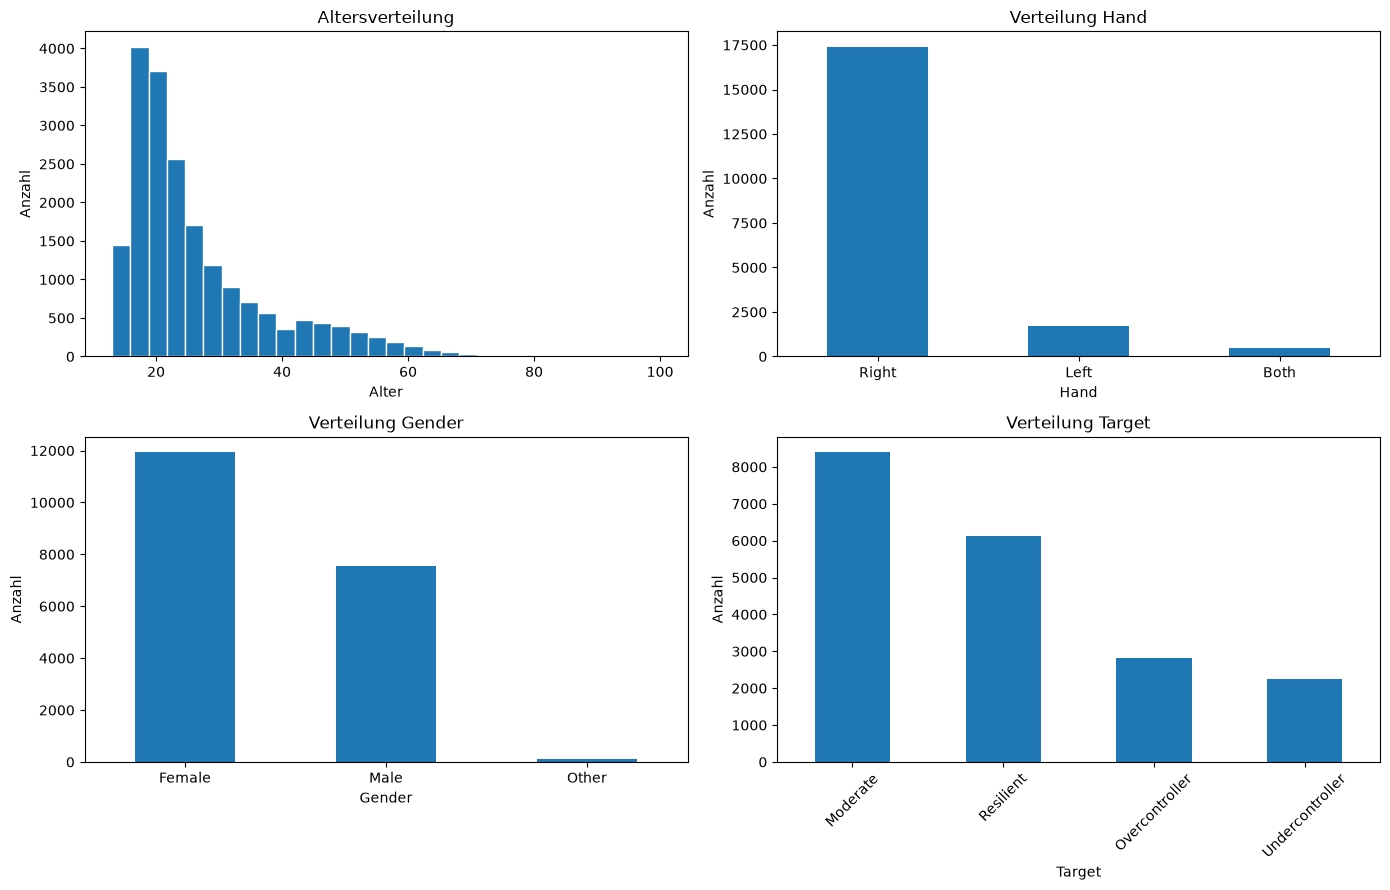

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

# Alter
axes[0].hist(df_clean["age"].dropna(), bins=30, edgecolor="white")
axes[0].set_title("Altersverteilung")
axes[0].set_xlabel("Alter")
axes[0].set_ylabel("Anzahl")

# Hand
df_clean["hand"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Verteilung Hand")
axes[1].set_xlabel("Hand")
axes[1].set_ylabel("Anzahl")
axes[1].tick_params(axis="x", rotation=0)

# Gender
df_clean["gender"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Verteilung Gender")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Anzahl")
axes[2].tick_params(axis="x", rotation=0)

# Target
df_clean["target"].value_counts().plot(kind="bar", ax=axes[3])
axes[3].set_title("Verteilung Target")
axes[3].set_xlabel("Target")
axes[3].set_ylabel("Anzahl")
axes[3].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()